<a href="https://colab.research.google.com/github/Cado87/Monai_projects/blob/main/Spleen%20segmentation/Rust_NIfTI_visualizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Install Rust Toolchain
Run this cell to install `rustup` and the Rust compiler (`rustc`, `cargo`).

In [1]:
!curl --proto '=https' --tlsv1.2 -sSf https://sh.rustup.rs | sh -s -- -y
import os
os.environ['PATH'] += ':/root/.cargo/bin'
!rustc --version

info: downloading installer
warn: It looks like you have an existing rustup settings file at:
warn: /root/.rustup/settings.toml
warn: Rustup will install the default toolchain as specified in the settings file,
warn: instead of the one inferred from the default host triple.
info: profile set to default
info: default host triple is x86_64-unknown-linux-gnu
info: syncing channel updates for stable-x86_64-unknown-linux-gnu
info: latest update on 2026-05-28 for version 1.96.0 (ac68faa20 2026-05-25)
info: downloading 6 components
        cargo unpacking   [#              ]   10.64 MiB (1.35 MiB/s, ETA: 8s)
        cargo unpacking   [#              ]   10.64 MiB (1.60 MiB/s, ETA: 7s)
        cargo unpacking   [#              ]   10.64 MiB (2.26 MiB/s, ETA: 5s)
       clippy pending installation             4.58 MiB
        cargo unpacking   [#              ]   10.64 MiB (2.74 MiB/s, ETA: 4s)
       clippy pending installation             4.58 MiB
        cargo unpacking   [##             ]  

### 2. Initialize the Rust Project
Let's create a new Cargo project called `nifti_viewer` and add the `nifti` crate as a dependency.

In [2]:
!cargo new nifti_viewer
%cd nifti_viewer
!cargo add nifti
!cargo add ndarray # Useful for multi-dimensional array manipulation

    Creating binary (application) `nifti_viewer` package
note: see more `Cargo.toml` keys and their definitions at https://doc.rust-lang.org/cargo/reference/manifest.html
/content/nifti_viewer
    Updating crates.io index
      Adding nifti v0.17.0 to dependencies
             Features:
             + ndarray
             + ndarray_volumes
             - nalgebra
             - nalgebra_affine
             - simba
    Updating crates.io index
     Locking 28 packages to latest Rust 1.96.0 compatible versions
    Updating crates.io index
      Adding ndarray v0.17.2 to dependencies
             Features:
             + std
             - approx
             - blas
             - matrixmultiply-threading
             - portable-atomic-critical-section
             - rayon
             - serde
    Updating crates.io index
     Locking 1 package to latest Rust 1.96.0 compatible version
      Adding ndarray v0.17.2


### 3. Write a Basic NIfTI Reader in Rust
This will write a simple Rust program to `src/main.rs` that attempts to load a NIfTI file and print its header information.

In [3]:
%%writefile src/main.rs
use nifti::{NiftiObject, ReaderOptions};

fn main() {
    // Replace this with the path to one of your U-Net output NIfTI files
    let file_path = "test.nii.gz";

    println!("Attempting to load NIfTI file: {}", file_path);

    // Read the NIfTI file
    match ReaderOptions::new().read_file(file_path) {
        Ok(obj) => {
            let header = obj.header();
            println!("Successfully loaded NIfTI file!");
            println!("Dimensions: {:?}", header.dim);
            println!("Data type: {:?}", header.datatype);
        },
        Err(e) => {
            println!("Error loading NIfTI file: {:?}. Please ensure you have downloaded a sample .nii.gz file to this directory.", e);
        }
    }
}

Overwriting src/main.rs


In [4]:
!cargo build

  Downloaded approx v0.5.1
  Downloaded autocfg v1.5.1
  Downloaded crc32fast v1.5.0
  Downloaded matrixmultiply v0.3.10
  Downloaded quote v1.0.45
  Downloaded rgb v0.8.53
  Downloaded simd-adler32 v0.3.9
  Downloaded unicode-ident v1.0.24
  Downloaded nifti v0.17.0
  Downloaded miniz_oxide v0.8.9
  Downloaded flate2 v1.1.9
  Downloaded num-traits v0.2.19
  Downloaded byteordered v0.6.0
  Downloaded bytemuck v1.25.0
  Downloaded rawpointer v0.2.1
  Downloaded quick-error v2.0.1
  Downloaded proc-macro2 v1.0.106
  Downloaded ndarray v0.17.2
  Downloaded either v1.16.0
  Downloaded ndarray v0.16.1
  Downloaded syn v2.0.117
  Downloaded num-integer v0.1.46
  Downloaded num-derive v0.4.2
  Downloaded num-complex v0.4.6
  Downloaded byteorder v1.5.0
  Downloaded adler2 v2.0.1
  Downloaded cfg-if v1.0.4
   Compiling autocfg v1.5.1
   Compiling proc-macro2 v1.0.106
   Compiling num-traits v0.2.19
   Compiling matrixmultiply v0.3.10
   Compiling quote v1.0.45
   Compiling unicode-ident v1.0.2

### 4. Download a Sample NIfTI file and Run
Let's get a small sample `.nii.gz` file so our Rust program can read it.

In [5]:
import nibabel as nib
import numpy as np

# Create a simple 3D numpy array to simulate a medical volume
data = np.zeros((32, 32, 32), dtype=np.int16)
data[10:22, 10:22, 10:22] = 1  # Add a dummy 'spleen' segment

# Create a NIfTI image using an identity affine matrix
img = nib.Nifti1Image(data, np.eye(4))

# Save the image to the current directory as test.nii.gz
filename = 'test.nii.gz'
nib.save(img, filename)

print(f"Dummy NIfTI file '{filename}' created successfully!")

Dummy NIfTI file 'test.nii.gz' created successfully!


In [6]:
!cargo run

    Finished `dev` profile [unoptimized + debuginfo] target(s) in 0.03s
     Running `target/debug/nifti_viewer`
Attempting to load NIfTI file: test.nii.gz
Successfully loaded NIfTI file!
Dimensions: [3, 32, 32, 32, 1, 1, 1, 1]
Data type: 4


### 5. Extract and Render a Slice using Rust
Let's add the `image` crate to process and save a 2D slice from our 3D volume as a PNG file.

In [7]:
!cargo add image

    Updating crates.io index
      Adding image v0.25.10 to dependencies
             Features:
             + avif
             + bmp
             + dds
             + default-formats
             + exr
             + ff
             + gif
             + hdr
             + ico
             + jpeg
             + png
             + pnm
             + qoi
             + rayon
             + tga
             + tiff
             + webp
             - avif-native
             - benchmarks
             - color_quant
             - nasm
             - serde
    Updating crates.io index
     Locking 90 packages to latest Rust 1.96.0 compatible versions
      Adding aligned v0.4.3
      Adding aligned-vec v0.6.4
      Adding anyhow v1.0.102
      Adding arbitrary v1.4.2
      Adding arg_enum_proc_macro v0.3.4
      Adding arrayvec v0.7.6
      Adding as-slice v0.2.1
      Adding av-scenechange v0.14.1
      Adding av1-grain v0.2.5
      Adding avif-serialize v0.8.9
      Adding bit_field v0.10.

In [8]:
%%writefile src/main.rs
use nifti::{IntoNdArray, NiftiObject, ReaderOptions};
use image::{ImageBuffer, Luma};

fn main() {
    let file_path = "test.nii.gz";
    println!("Loading NIfTI file: {}", file_path);

    // Read the NIfTI file and convert the volume to an ndarray
    let obj = ReaderOptions::new().read_file(file_path).expect("Failed to read NIfTI");
    let volume = obj.into_volume();
    let ndarray = volume.into_ndarray::<f32>().expect("Failed to convert to ndarray");

    let shape = ndarray.shape();
    println!("Data shape: {:?}", shape);

    // We know our dummy data is 3D. Let's get the middle slice on the Z axis.
    let width = shape[0];
    let height = shape[1];
    let depth = shape[2];
    let z_slice = depth / 2;

    // Create a new grayscale image buffer
    let mut imgbuf = ImageBuffer::new(width as u32, height as u32);

    for x in 0..width {
        for y in 0..height {
            // Access the voxel value
            let val = ndarray[[x, y, z_slice]];

            // Normalize the value. Ensure it's an 8-bit unsigned integer (u8)
            // Our dummy data has values 0 (background) and 1 (spleen segment).
            let pixel_val: u8 = if val > 0.5 { 255 } else { 0 };

            imgbuf.put_pixel(x as u32, y as u32, Luma([pixel_val]));
        }
    }

    // Save the resulting slice as a PNG
    let output_file = "slice.png";
    imgbuf.save(output_file).expect("Failed to save image");
    println!("Successfully saved middle slice to {}", output_file);
}

Overwriting src/main.rs


In [9]:
!cargo run

  Downloaded aligned-vec v0.6.4
  Downloaded aligned v0.4.3
  Downloaded arg_enum_proc_macro v0.3.4
  Downloaded avif-serialize v0.8.9
  Downloaded equator-macro v0.4.2
  Downloaded zune-core v0.5.1
  Downloaded weezl v0.1.12
  Downloaded ravif v0.13.0
  Downloaded zune-inflate v0.2.54
  Downloaded zune-jpeg v0.5.15
  Downloaded zerocopy-derive v0.8.52
  Downloaded num-bigint v0.4.6
  Downloaded png v0.18.1
  Downloaded memchr v2.8.2
  Downloaded rayon v1.12.0
  Downloaded moxcms v0.8.1
  Downloaded nom v8.0.0
  Downloaded exr v1.74.0
  Downloaded zerocopy v0.8.52
  Downloaded itertools v0.14.0
  Downloaded wasm-bindgen-macro-support v0.2.125
  Downloaded tiff v0.11.3
  Downloaded bumpalo v3.20.3
  Downloaded image v0.25.10
  Downloaded wasm-bindgen v0.2.125
  Downloaded smallvec v1.15.2
  Downloaded rayon-core v1.13.0
  Downloaded av-scenechange v0.14.1
  Downloaded qoi v0.4.1
  Downloaded once_cell v1.21.4
  Downloaded no_std_io2 v0.9.4
  Downloaded image-webp v0.2.4
  Downloaded hal

Displaying the rendered NIfTI slice:


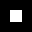

In [10]:
from IPython.display import Image, display
import os

if os.path.exists('slice.png'):
    print("Displaying the rendered NIfTI slice:")
    display(Image('slice.png', width=200))
else:
    print("slice.png not found. Make sure the Rust code ran successfully.")

### 6. Visualize a Real NIfTI Image
First, let's download and extract the dataset.

In [11]:
!wget -qO- https://msd-for-monai.s3-us-west-2.amazonaws.com/Task09_Spleen.tar | tar -xvf -
!ls Task09_Spleen/imagesTr | head -n 5

./._Task09_Spleen
Task09_Spleen/
Task09_Spleen/._labelsTr
Task09_Spleen/labelsTr/
Task09_Spleen/._imagesTr
Task09_Spleen/imagesTr/
Task09_Spleen/._imagesTs
Task09_Spleen/imagesTs/
Task09_Spleen/._dataset.json
Task09_Spleen/dataset.json
Task09_Spleen/imagesTs/._spleen_15.nii.gz
Task09_Spleen/imagesTs/spleen_15.nii.gz
Task09_Spleen/imagesTs/._spleen_23.nii.gz
Task09_Spleen/imagesTs/spleen_23.nii.gz
Task09_Spleen/imagesTs/._spleen_1.nii.gz
Task09_Spleen/imagesTs/spleen_1.nii.gz
Task09_Spleen/imagesTs/._spleen_42.nii.gz
Task09_Spleen/imagesTs/spleen_42.nii.gz
Task09_Spleen/imagesTs/._spleen_50.nii.gz
Task09_Spleen/imagesTs/spleen_50.nii.gz
Task09_Spleen/imagesTs/._spleen_54.nii.gz
Task09_Spleen/imagesTs/spleen_54.nii.gz
Task09_Spleen/imagesTs/._spleen_37.nii.gz
Task09_Spleen/imagesTs/spleen_37.nii.gz
Task09_Spleen/imagesTs/._spleen_58.nii.gz
Task09_Spleen/imagesTs/spleen_58.nii.gz
Task09_Spleen/imagesTs/._spleen_39.nii.gz
Task09_Spleen/imagesTs/spleen_39.nii.gz
Task09_Spleen/imagesTs/._spl

In [12]:
%%writefile src/main.rs
use nifti::{IntoNdArray, NiftiObject, ReaderOptions};
use image::{ImageBuffer, Luma};

fn main() {
    // Point to a real file from the downloaded dataset
    let file_path = "Task09_Spleen/imagesTr/spleen_10.nii.gz";
    println!("Loading NIfTI file: {}", file_path);

    // Read the NIfTI file and convert the volume to an ndarray
    let obj = ReaderOptions::new().read_file(file_path).expect("Failed to read NIfTI");
    let volume = obj.into_volume();
    let ndarray = volume.into_ndarray::<f32>().expect("Failed to convert to ndarray");

    let shape = ndarray.shape();
    println!("Data shape: {:?}", shape);

    let width = shape[0];
    let height = shape[1];
    let depth = shape[2];
    let z_slice = depth / 2; // Extract the middle slice

    // Find min and max values in this specific slice for normalization
    let mut min_val = f32::MAX;
    let mut max_val = f32::MIN;
    for x in 0..width {
        for y in 0..height {
            let val = ndarray[[x, y, z_slice]];
            if val < min_val { min_val = val; }
            if val > max_val { max_val = val; }
        }
    }

    println!("Slice Min: {}, Max: {}", min_val, max_val);

    // Create a new grayscale image buffer
    let mut imgbuf = ImageBuffer::new(width as u32, height as u32);

    for x in 0..width {
        for y in 0..height {
            let val = ndarray[[x, y, z_slice]];

            // Normalize the value to 0.0 - 1.0
            let mut norm = (val - min_val) / (max_val - min_val);
            if norm < 0.0 { norm = 0.0; }
            if norm > 1.0 { norm = 1.0; }

            // Scale to 0-255 for the image pixel
            let pixel_val = (norm * 255.0) as u8;
            imgbuf.put_pixel(x as u32, y as u32, Luma([pixel_val]));
        }
    }

    // Save the resulting slice as a PNG
    let output_file = "real_slice.png";
    imgbuf.save(output_file).expect("Failed to save image");
    println!("Successfully saved real middle slice to {}", output_file);
}


Overwriting src/main.rs


In [13]:
!cargo run

   Compiling nifti_viewer v0.1.0 (/content/nifti_viewer)
    Finished `dev` profile [unoptimized + debuginfo] target(s) in 1.10s
     Running `target/debug/nifti_viewer`
Loading NIfTI file: Task09_Spleen/imagesTr/spleen_10.nii.gz
Data shape: [512, 512, 55]
Slice Min: -1024, Max: 3072
Successfully saved real middle slice to real_slice.png


Displaying the rendered real NIfTI slice:


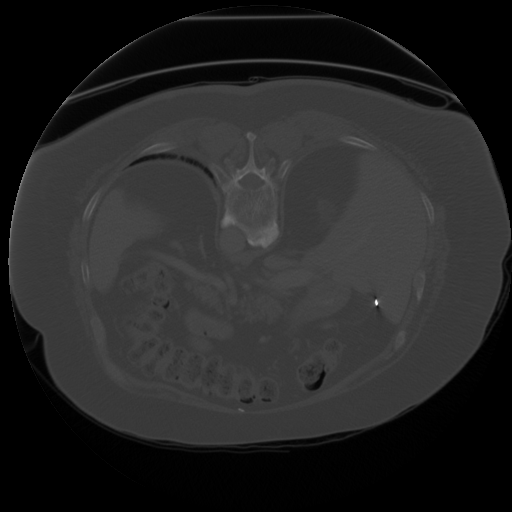

In [14]:
from IPython.display import Image, display
import os

if os.path.exists('real_slice.png'):
    print("Displaying the rendered real NIfTI slice:")
    display(Image('real_slice.png', width=400))
else:
    print("real_slice.png not found. Make sure the Rust code ran successfully.")

### 7. Run Spleen Segmentation Inference (MONAI)
Make sure to upload your `best_metric_model.pth` from your previous training session into the current directory before running the following code.

In [15]:
!pip install -q "monai[nibabel]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 46.7 MB/s eta 0:00:00


In [16]:
import os
import torch
import matplotlib.pyplot as plt
import monai
from monai.networks.nets import UNet
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Spacingd,
    ScaleIntensityRanged,
    EnsureTyped,
)
from monai.inferers import sliding_window_inference

model_path = "best_metric_model.pth"

if not os.path.exists(model_path):
    print(f"⚠️ Please upload your trained '{model_path}' to the current directory!")
else:
    print("Model weights found! Setting up the MONAI UNet...")

    # Setup device and identical UNet architecture from the tutorial
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = UNet(
        spatial_dims=3,
        in_channels=1,
        out_channels=2,
        channels=(16, 32, 64, 128, 256),
        strides=(2, 2, 2, 2),
        num_res_units=2,
        norm="batch",
    ).to(device)

    # Load the trained weights
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Apply the same preprocessing transforms used during validation
    val_transforms = Compose([
        LoadImaged(keys=["image"]),
        EnsureChannelFirstd(keys=["image"]),
        Spacingd(keys=["image"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear")),
        ScaleIntensityRanged(keys=["image"], a_min=-57, a_max=164, b_min=0.0, b_max=1.0, clip=True),
        EnsureTyped(keys=["image"]),
    ])

    # Pick an image from the test set
    test_image_path = "Task09_Spleen/imagesTs/spleen_15.nii.gz"
    data = {"image": test_image_path}
    data = val_transforms(data)

    # Add batch dimension and move to device
    inputs = data["image"].unsqueeze(0).to(device)

    print("Running inference...")
    with torch.no_grad():
        outputs = sliding_window_inference(inputs, (160, 160, 160), 4, model)
        # Argmax to get the discrete segmentation mask
        pred_mask = torch.argmax(outputs, dim=1).squeeze().cpu().numpy()

    original_image = data["image"].squeeze().cpu().numpy()

    print(f"Inference complete! Output shape: {pred_mask.shape}")

    # Plotting the middle slice
    slice_idx = pred_mask.shape[2] // 2
    plt.figure("check", (12, 6))
    plt.subplot(1, 2, 1)
    plt.title(f"Original Image (slice {slice_idx})")
    plt.imshow(original_image[:, :, slice_idx], cmap="gray")

    plt.subplot(1, 2, 2)
    plt.title(f"Predicted Spleen Mask (slice {slice_idx})")
    plt.imshow(pred_mask[:, :, slice_idx], cmap="viridis")
    plt.show()

⚠️ Please upload your trained 'best_metric_model.pth' to the current directory!
